In [82]:
# Mantenimiento Predictivo Industrial

1. Introducción

# Predicción de fallas en maquinaria industrial

Este proyecto aplica técnicas de ciencia de datos para analizar las condiciones operativas de una máquina y predecir si puede ocurrir una falla.

El análisis se relaciona con Ingeniería Industrial porque puede apoyar el mantenimiento predictivo, la reducción de paradas no planificadas y la mejora de la disponibilidad de los equipos.

El dataset utilizado es el AI4I 2020 Predictive Maintenance Dataset.

2. Objetivos

## Objetivos
### Objetivo general
Analizar las condiciones operativas de maquinaria industrial y construir un
modelo de clasificación que permita predecir posibles fallas.
### Objetivos específicos

- Explorar las variables del conjunto de datos.
- Identificar valores faltantes, duplicados y posibles inconsistencias.
- Analizar la relación entre las variables operativas y las fallas.
- Construir un modelo de aprendizaje automático.
- Evaluar el desempeño del modelo mediante diferentes métricas.
- Analizar su posible aplicación en mantenimiento industrial.

3. Importación de librerías

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


sns.set_theme(style="whitegrid")

4. Carga de datos

## Carga de datos

Se carga el archivo CSV que contiene la información sobre las condiciones
operativas de las máquinas y la ocurrencia de fallas.

In [84]:
ruta = "/content/ai4i2020.csv"


df = pd.read_csv(ruta)


print("El dataset tiene", df.shape[0], "filas y", df.shape[1], "columnas")


df.head()

El dataset tiene 10000 filas y 14 columnas


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


5. Exploración inicial

## Exploración inicial


En esta etapa se revisan las dimensiones del dataset, los tipos de variables,
las estadísticas descriptivas, los valores faltantes y los registros duplicados.

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [86]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


In [87]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [88]:
print("Cantidad de filas y columnas:", df.shape)

Cantidad de filas y columnas: (10000, 14)


In [89]:
print("Cantidad de valores faltantes por columna:")
print(df.isnull().sum())

Cantidad de valores faltantes por columna:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [90]:
print("Cantidad de registros duplicados:",df.duplicated().sum())

Cantidad de registros duplicados: 0


6. Limpieza de datos

## Limpieza y transformación de datos


En esta etapa se renombran las columnas para facilitar el análisis, se revisan
los registros duplicados, se eliminan identificadores y se convierten las
temperaturas de Kelvin a grados Celsius.

In [91]:
df = df.rename(columns={
    "UDI": "id",
    "Product ID": "id_producto",
    "Type": "tipo_producto",
    "Air temperature [K]": "temperatura_aire",
    "Process temperature [K]": "temperatura_proceso",
    "Rotational speed [rpm]": "velocidad_rotacion",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "desgaste_herramienta",
    "Machine failure": "falla_maquina",
    "TWF": "falla_desgaste_herramienta",
    "HDF": "falla_disipacion_calor",
    "PWF": "falla_potencia",
    "OSF": "falla_sobrecarga",
    "RNF": "falla_aleatoria"
})


df.head()

,id,id_producto,tipo_producto,temperatura_aire,temperatura_proceso,velocidad_rotacion,torque,desgaste_herramienta,falla_maquina,falla_desgaste_herramienta,falla_disipacion_calor,falla_potencia,falla_sobrecarga,falla_aleatoria
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [92]:
duplicados_antes = df.duplicated().sum()


df = df.drop_duplicates()


duplicados_despues = df.duplicated().sum()


print("Duplicados antes de limpiar:", duplicados_antes)
print("Duplicados después de limpiar:", duplicados_despues)

Duplicados antes de limpiar: 0
Duplicados después de limpiar: 0


In [93]:
df["temperatura_aire_c"] = df["temperatura_aire"] - 273.15
df["temperatura_proceso_c"] = df["temperatura_proceso"] - 273.15


df[
    [
        "temperatura_aire",
        "temperatura_aire_c",
        "temperatura_proceso",
        "temperatura_proceso_c"
    ]
].head()

,temperatura_aire,temperatura_aire_c,temperatura_proceso,temperatura_proceso_c
0,298.1,24.95,308.6,35.45
1,298.2,25.05,308.7,35.55
2,298.1,24.95,308.5,35.35
3,298.2,25.05,308.6,35.45
4,298.2,25.05,308.7,35.55


Las temperaturas originales estaban expresadas en Kelvin. Para facilitar la
interpretación en el contexto de Ingeniería Industrial, se crearon nuevas
variables en grados Celsius utilizando la fórmula:


Temperatura en Celsius = Temperatura en Kelvin - 273.15

In [94]:
columnas_eliminar = [
    "id",
    "id_producto",
    "temperatura_aire",
    "temperatura_proceso",
    "falla_desgaste_herramienta",
    "falla_disipacion_calor",
    "falla_potencia",
    "falla_sobrecarga",
    "falla_aleatoria"
]


df_modelo = df.drop(
    columns=[
        columna for columna in columnas_eliminar
        if columna in df.columns
    ]
)


df_modelo.head()

,tipo_producto,velocidad_rotacion,torque,desgaste_herramienta,falla_maquina,temperatura_aire_c,temperatura_proceso_c
0,M,1551,42.8,0,0,24.95,35.45
1,L,1408,46.3,3,0,25.05,35.55
2,L,1498,49.4,5,0,24.95,35.35
3,L,1433,39.5,7,0,25.05,35.45
4,L,1408,40.0,9,0,25.05,35.55


In [95]:
print(df_modelo.columns.tolist())
print(df_modelo.shape)

['tipo_producto', 'velocidad_rotacion', 'torque', 'desgaste_herramienta', 'falla_maquina', 'temperatura_aire_c', 'temperatura_proceso_c']
(10000, 7)


7. Análisis exploratorio

## Análisis exploratorio


En esta etapa se analiza la distribución de las fallas y se comparan las
variables operativas de las máquinas que presentaron fallas con aquellas que no
presentaron fallas.

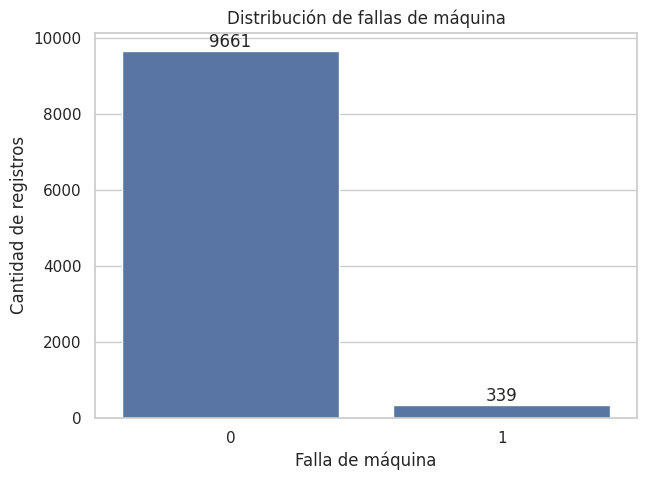

In [96]:
plt.figure(figsize=(7, 5))


ax = sns.countplot(
    data=df_modelo,
    x="falla_maquina"
)


plt.title("Distribución de fallas de máquina")
plt.xlabel("Falla de máquina")
plt.ylabel("Cantidad de registros")


for container in ax.containers:
    ax.bar_label(container)


plt.show()

In [97]:
porcentajes_falla = (
    df_modelo["falla_maquina"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print(porcentajes_falla)

falla_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64


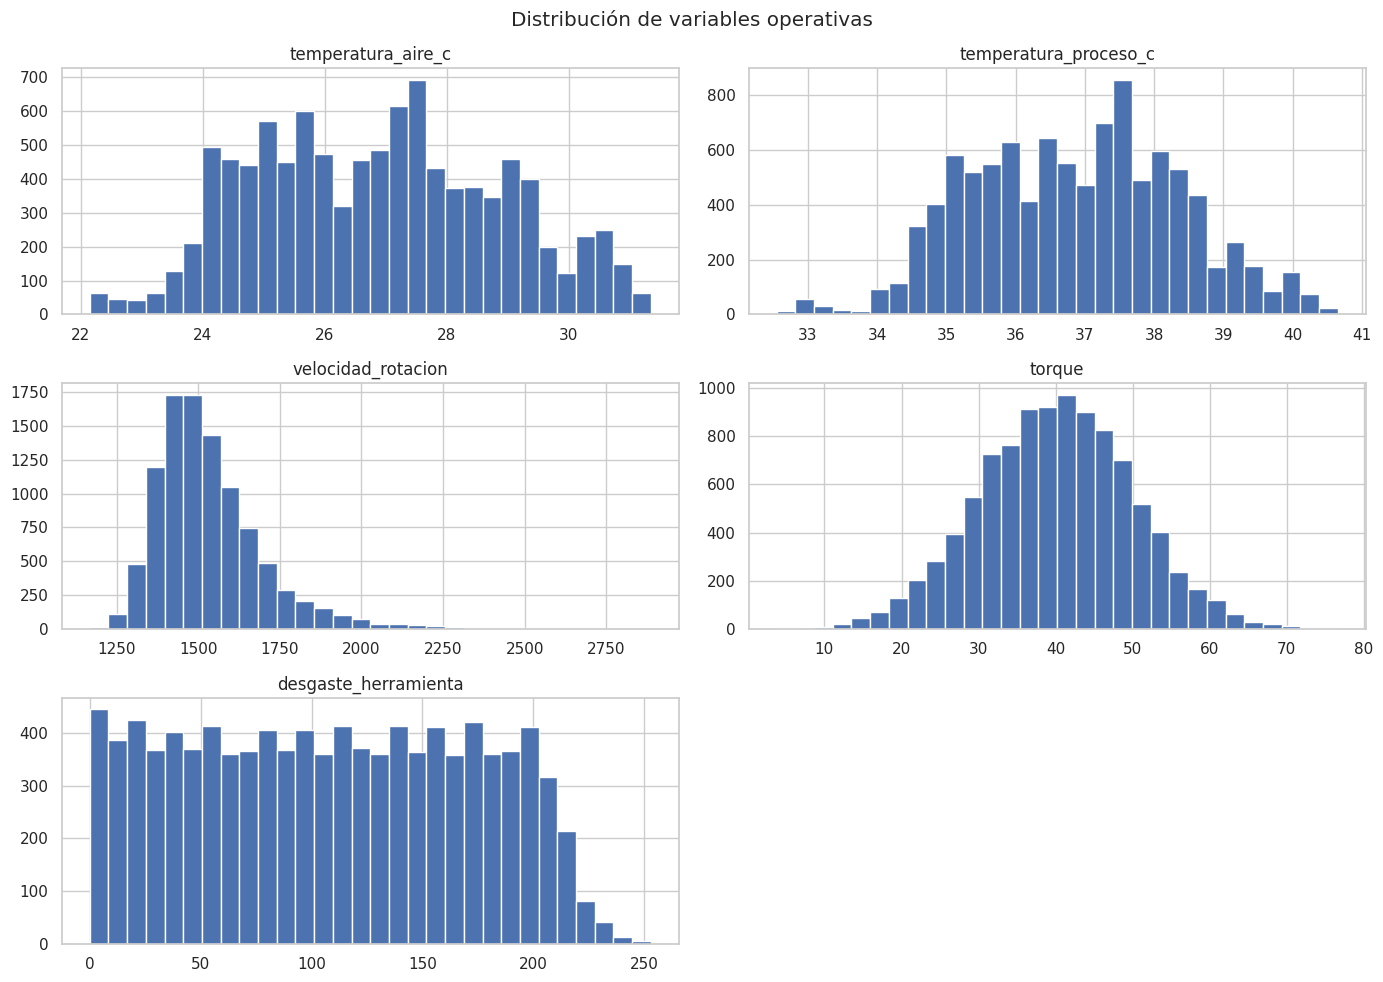

In [98]:
variables_numericas = [
    "temperatura_aire_c",
    "temperatura_proceso_c",
    "velocidad_rotacion",
    "torque",
    "desgaste_herramienta"
]


df_modelo[variables_numericas].hist(
    figsize=(14, 10),
    bins=30
)


plt.suptitle("Distribución de variables operativas")
plt.tight_layout()
plt.show()

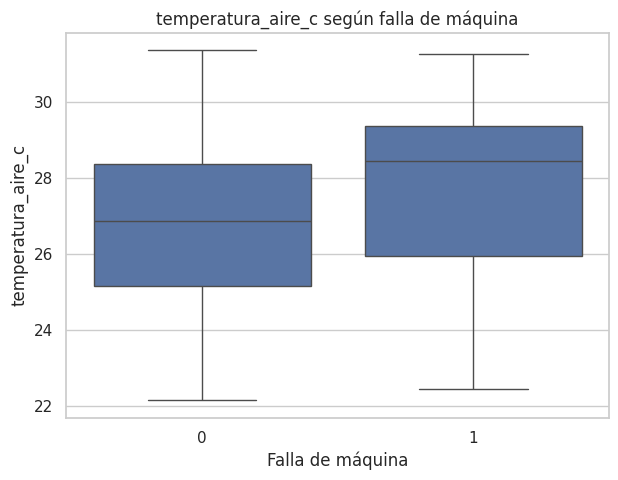

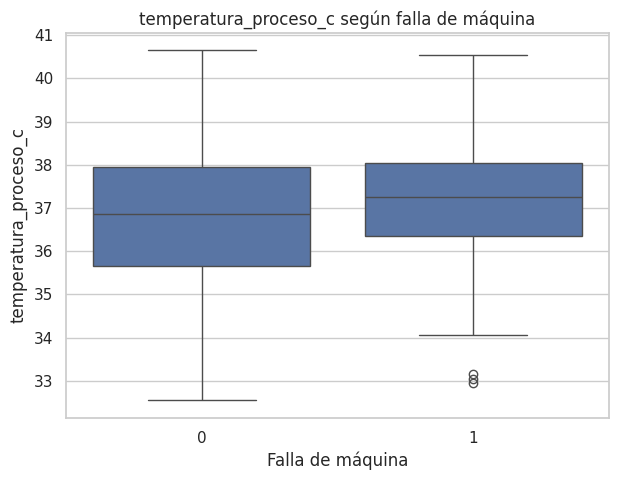

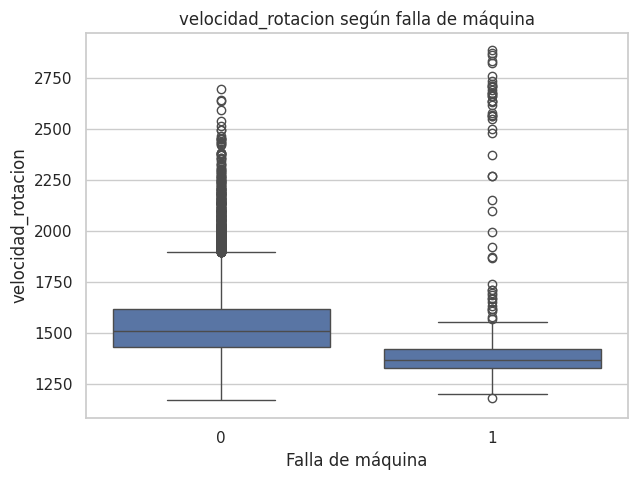

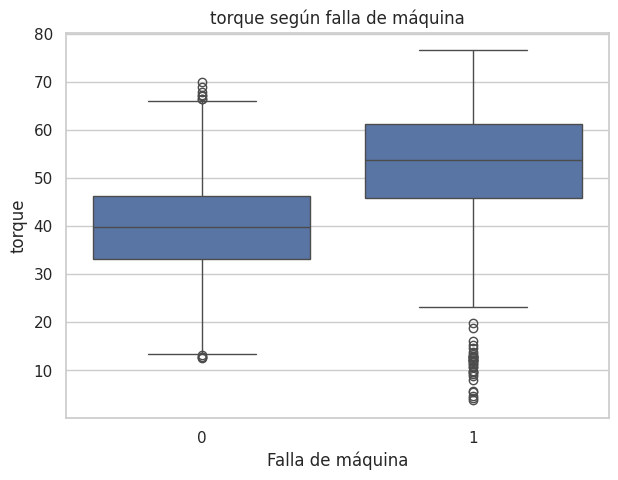

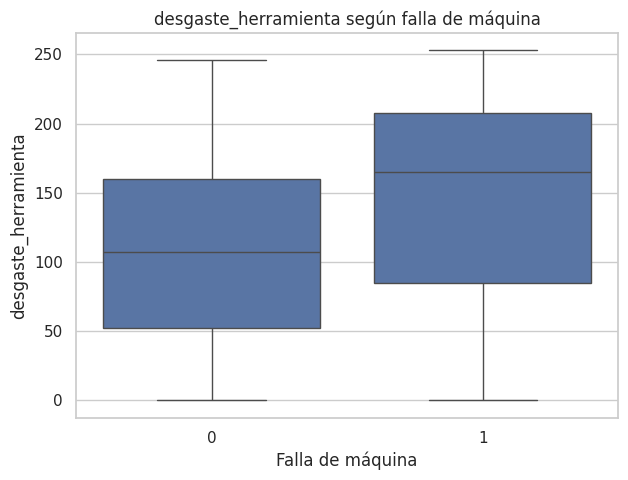

In [70]:
for variable in variables_numericas:
    plt.figure(figsize=(7, 5))


    sns.boxplot(
        data=df_modelo,
        x="falla_maquina",
        y=variable
    )


    plt.title(f"{variable} según falla de máquina")
    plt.xlabel("Falla de máquina")
    plt.ylabel(variable)


    plt.show()

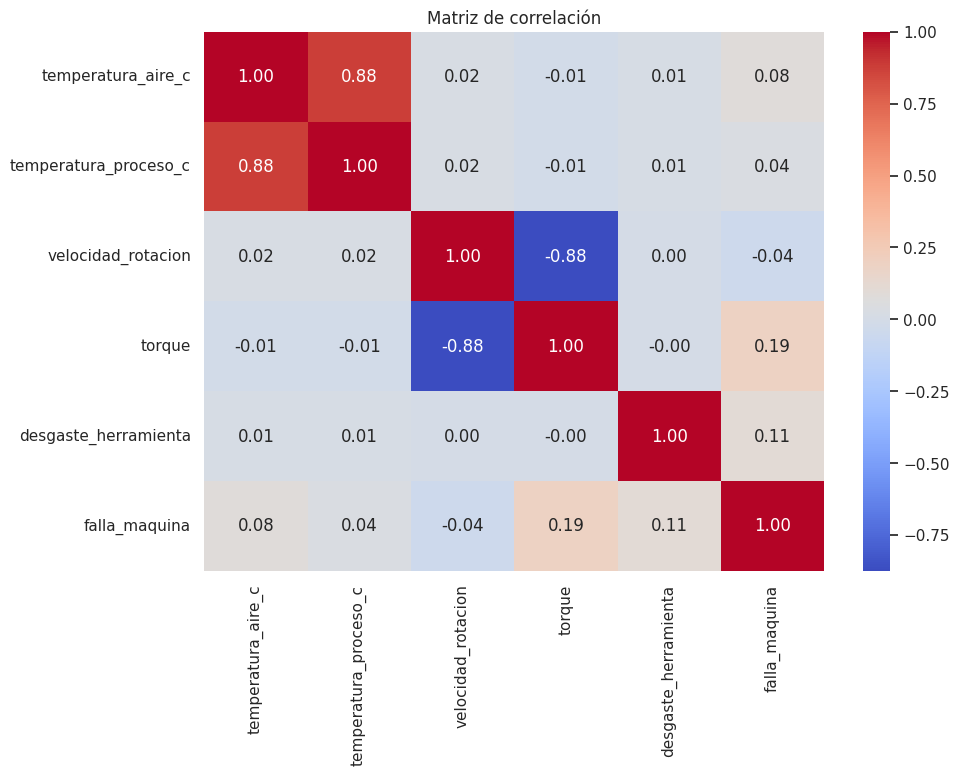

In [71]:
plt.figure(figsize=(10, 7))


correlaciones = df_modelo[
    variables_numericas + ["falla_maquina"]
].corr()


sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)


plt.title("Matriz de correlación")
plt.show()

Los gráficos permiten comparar el comportamiento de las variables operativas
entre las máquinas con y sin falla. Las diferencias observadas representan
asociaciones en los datos, pero no demuestran que una variable sea la causa
directa de una falla.

8. Construcción del modelo

## Construcción del modelo


Se utilizará un modelo Random Forest para clasificar las máquinas según la
probabilidad de que presenten una falla.


Los datos se dividirán en un conjunto de entrenamiento y un conjunto de prueba.
El 80 % se utilizará para entrenar el modelo y el 20 % para evaluarlo.

In [72]:
X = df_modelo.drop(columns=["falla_maquina"])
y = df_modelo["falla_maquina"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (8000, 6)
Datos de prueba: (2000, 6)


In [73]:
variables_numericas_modelo = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


variables_categoricas_modelo = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("Variables numéricas:", variables_numericas_modelo)
print("Variables categóricas:", variables_categoricas_modelo)

Variables numéricas: ['velocidad_rotacion', 'torque', 'desgaste_herramienta', 'temperatura_aire_c', 'temperatura_proceso_c']
Variables categóricas: ['tipo_producto']


In [74]:
preprocesador_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler())
    ]
)


preprocesador_categorico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)


preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            preprocesador_numerico,
            variables_numericas_modelo
        ),
        (
            "categoricas",
            preprocesador_categorico,
            variables_categoricas_modelo
        )
    ]
)

In [75]:
modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "clasificador",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [76]:
modelo.fit(X_train, y_train)


predicciones = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)[:, 1]


print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


9. Evaluación del modelo

## Evaluación del modelo


El modelo se evaluará utilizando exactitud, precisión, sensibilidad, F1-score y
AUC. Debido a que las fallas pueden ser menos frecuentes que los casos sin
falla, no se utilizará únicamente la exactitud.

In [77]:
metricas = {
    "Exactitud": accuracy_score(y_test, predicciones),
    "Precisión": precision_score(
        y_test,
        predicciones,
        zero_division=0
    ),
    "Sensibilidad": recall_score(
        y_test,
        predicciones,
        zero_division=0
    ),
    "F1-score": f1_score(
        y_test,
        predicciones,
        zero_division=0
    ),
    "AUC": roc_auc_score(y_test, probabilidades)
}


tabla_metricas = pd.DataFrame(
    metricas.items(),
    columns=["Métrica", "Resultado"]
)


tabla_metricas

,Métrica,Resultado
0,Exactitud,0.979000
1,Precisión,0.933333
2,Sensibilidad,0.411765
3,F1-score,0.571429
4,AUC,0.964457


In [78]:
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.93      0.41      0.57        68

    accuracy                           0.98      2000
   macro avg       0.96      0.71      0.78      2000
weighted avg       0.98      0.98      0.98      2000



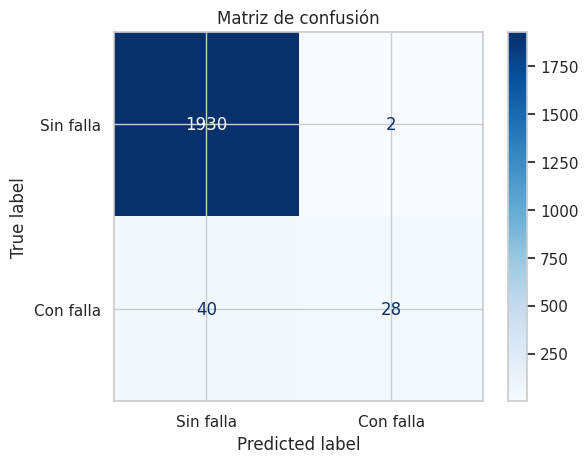

In [79]:
matriz = confusion_matrix(y_test, predicciones)


disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Sin falla", "Con falla"]
)


disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

10. Interpretación de resultados

## Interpretación de resultados


La sensibilidad indica la capacidad del modelo para identificar correctamente
las máquinas que realmente presentaron una falla.


La precisión indica qué proporción de las máquinas clasificadas como defectuosas
realmente presentó una falla.


En un contexto industrial, un falso negativo puede ser especialmente
importante porque una falla no detectada podría provocar una parada no
planificada. Por otro lado, un falso positivo podría ocasionar una inspección o
un mantenimiento innecesario.


Por esta razón, la métrica más importante dependerá de los costos asociados a
cada tipo de error.

In [80]:
preprocesamiento_ajustado = modelo.named_steps["preprocesamiento"]
clasificador = modelo.named_steps["clasificador"]


nombres_variables = (
    preprocesamiento_ajustado
    .get_feature_names_out()
)


importancias = clasificador.feature_importances_


importancia_variables = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": importancias
}).sort_values(
    by="importancia",
    ascending=False
)


importancia_variables.head(10)

,variable,importancia
1,numericas__torque,0.315593
0,numericas__velocidad_rotacion,0.281953
2,numericas__desgaste_herramienta,0.203795
3,numericas__temperatura_aire_c,0.105297
4,numericas__temperatura_proceso_c,0.073580
6,categoricas__tipo_producto_L,0.009080
7,categoricas__tipo_producto_M,0.006443
5,categoricas__tipo_producto_H,0.004258


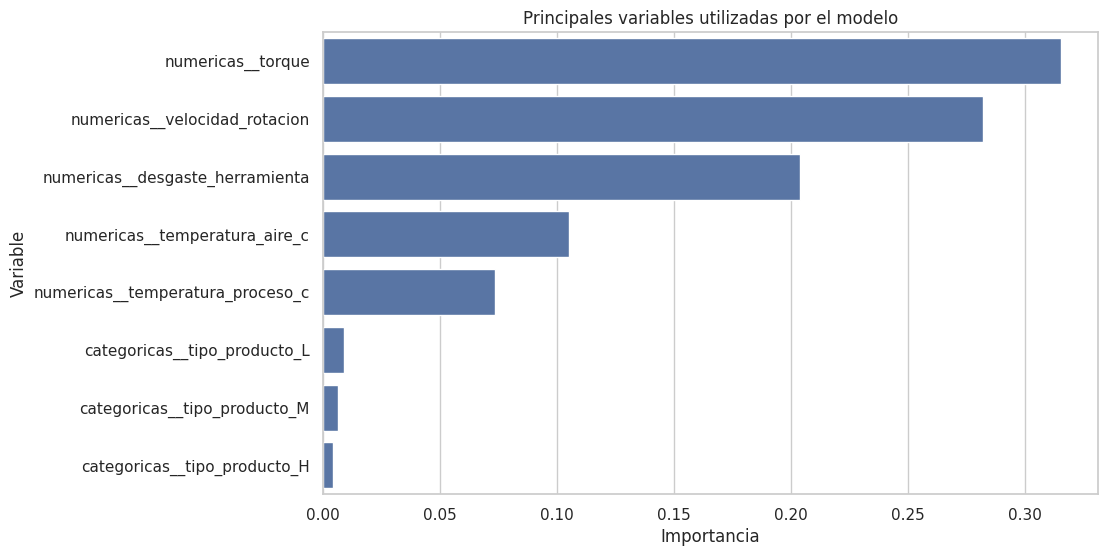

In [81]:
plt.figure(figsize=(10, 6))


sns.barplot(
    data=importancia_variables.head(10),
    x="importancia",
    y="variable"
)


plt.title("Principales variables utilizadas por el modelo")
plt.xlabel("Importancia")
plt.ylabel("Variable")


plt.show()

Las variables con mayor importancia contribuyeron más a las decisiones del
modelo. Sin embargo, la importancia de una variable no demuestra causalidad.
Es decir, no significa necesariamente que esa variable sea la causa directa de
la falla.

11. Conclusiones

## Conclusiones


El proyecto permitió aplicar un flujo completo de ciencia de datos a un problema
relacionado con el mantenimiento industrial.


Durante el análisis se exploraron las variables, se revisaron los datos, se
eliminaron identificadores, se transformaron las temperaturas de Kelvin a
Celsius y se construyó un modelo Random Forest.


El modelo permitió clasificar máquinas con y sin falla utilizando sus
condiciones operativas. Las métricas obtenidas deben interpretarse considerando
el desbalance de las clases y el costo de los falsos positivos y falsos
negativos.


Desde la perspectiva de Ingeniería Industrial, este tipo de herramienta podría
apoyar la priorización de inspecciones y la planificación del mantenimiento
predictivo.


Sin embargo, el dataset es sintético y el modelo debe validarse con datos reales
de una planta antes de utilizarse en un entorno profesional.